In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import random

In [2]:
def rbf_kernel(X, Y, gamma):
    """Compute RBF (Gaussian) kernel matrix between X and Y."""
    X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y ** 2, axis=1).reshape(1, -1)
    dist_sq = X_sq + Y_sq - 2 * X @ Y.T
    return np.exp(-gamma * dist_sq)

### Load Yale Faces Dataset

Number of persons: 15

n_train = 5, n_test = 1 (selected from remaining 6)
Training set: 75 images
Test set: 15 images
Feature dimension: 77760
Image size: (243, 320)
Training matrix: (75, 77760), Test matrix: (15, 77760)


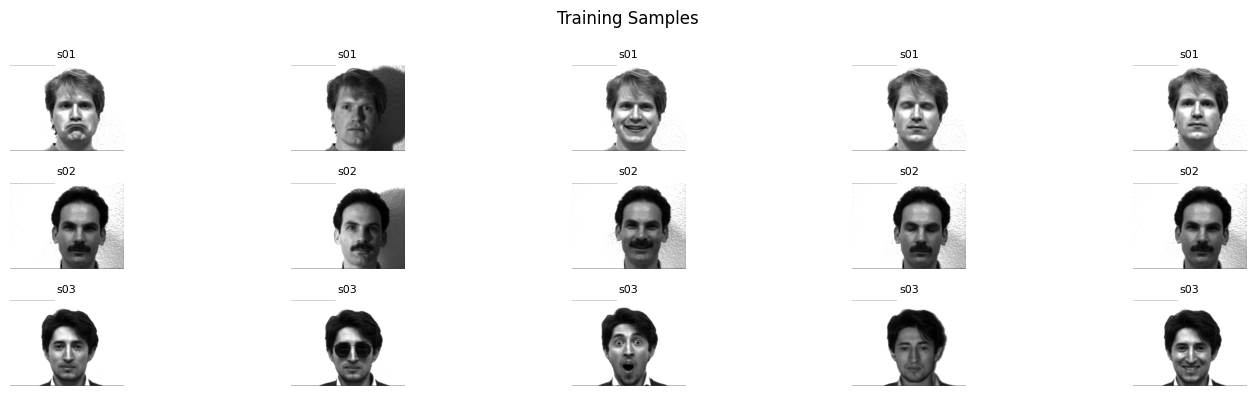

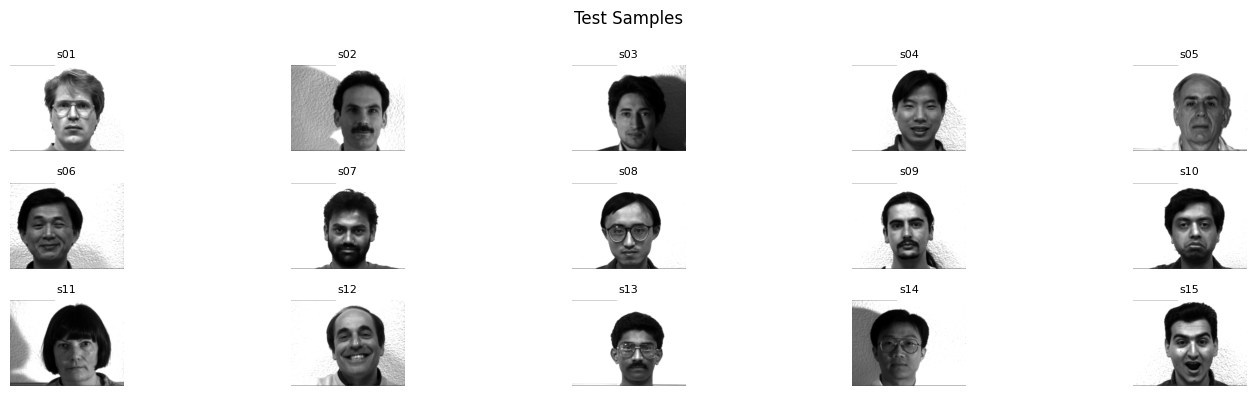

In [3]:
def load_yale_faces(path):
    """Load all Yale faces, grouped by person"""
    persons = {}
    for folder in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder)
        if os.path.isdir(folder_path):
            imgs = []
            for f in sorted(os.listdir(folder_path)):
                filepath = os.path.join(folder_path, f)
                if os.path.isfile(filepath):
                    try:
                        img = Image.open(filepath)
                        imgs.append(np.array(img, dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_data(persons, n_train, seed=42):
    """
    Split data: randomly select n_train images for training per person,
    then randomly select 1 image from the remaining as test.
    """
    random.seed(seed)
    train_imgs, train_labels = [], []
    test_imgs, test_labels = [], []

    for label, imgs in persons.items():
        if len(imgs) <= n_train:
            raise ValueError(
                f"Person '{label}' has only {len(imgs)} images, "
                f"need at least {n_train + 1} (n_train={n_train} + 1 for test)."
            )
        indices = list(range(len(imgs)))
        random.shuffle(indices)

        # First n_train shuffled indices -> training
        train_indices = indices[:n_train]
        # From remaining, randomly pick 1 -> test
        remaining = indices[n_train:]
        test_index = random.choice(remaining)

        for i in train_indices:
            train_imgs.append(imgs[i])
            train_labels.append(label)

        test_imgs.append(imgs[test_index])
        test_labels.append(label)

    return train_imgs, train_labels, test_imgs, test_labels

# Load data
persons = load_yale_faces("Datasets/yalefaces")
print(f"Number of persons: {len(persons)}")

n_train = 5  # Increased from 4 to 5 for more training data

train_imgs, train_labels, test_imgs, test_labels = split_data(persons, n_train=n_train)

X_train = np.array([img.flatten() for img in train_imgs])
X_test = np.array([img.flatten() for img in test_imgs])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

n_imgs_per_person = len(next(iter(persons.values())))
print(f"\nn_train = {n_train}, n_test = 1 (selected from remaining {n_imgs_per_person - n_train})")
print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"Feature dimension: {X_train.shape[1]}")

print(f"Image size: {train_imgs[0].shape}")
print(f"Training matrix: {X_train.shape}, Test matrix: {X_test.shape}")

# Visualize some training samples
fig, axes = plt.subplots(3, 5, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(train_imgs):
        ax.imshow(train_imgs[i], cmap='gray')
        ax.set_title(f"{train_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Training Samples")
plt.tight_layout()
plt.show()

# Visualize some test samples
fig, axes = plt.subplots(3, 5, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(test_imgs):
        ax.imshow(test_imgs[i], cmap='gray')
        ax.set_title(f"{test_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Test Samples")
plt.tight_layout()
plt.show()

### Training Kernel Matrix 

In [4]:
# Tune gamma via grid search over a range of values
gamma_list = [1e-11, 5e-11, 1e-10, 5e-10, 1e-9, 5e-9, 1e-8, 5e-8, 1e-7]
best_gamma = None
best_gamma_acc = 0

for g in gamma_list:
    K_tmp = rbf_kernel(X_train, X_train, g)
    N_tmp = K_tmp.shape[0]
    one_tmp = np.ones((N_tmp, N_tmp)) / N_tmp
    K_c_tmp = K_tmp - one_tmp @ K_tmp - K_tmp @ one_tmp + one_tmp @ K_tmp @ one_tmp
    ev_tmp, evec_tmp = np.linalg.eigh(K_c_tmp)
    idx_tmp = np.argsort(ev_tmp)[::-1]
    ev_tmp = ev_tmp[idx_tmp]; evec_tmp = evec_tmp[:, idx_tmp]
    pos_tmp = ev_tmp > 1e-10
    ev_tmp = ev_tmp[pos_tmp]; evec_tmp = evec_tmp[:, pos_tmp]
    al_tmp = evec_tmp / np.sqrt(ev_tmp)
    Xtr_p = K_c_tmp @ al_tmp

    K_te_tmp = rbf_kernel(X_test, X_train, g)
    N_te = X_test.shape[0]
    one_te = np.ones((N_te, N_tmp)) / N_tmp
    K_te_c = K_te_tmp - one_te @ K_tmp - K_te_tmp @ one_tmp + one_te @ K_tmp @ one_tmp
    Xte_p = K_te_c @ al_tmp

    for k in range(1, min(Xtr_p.shape[1], N_tmp)+1):
        dists = np.linalg.norm(Xte_p[:, np.newaxis, :k] - Xtr_p[np.newaxis, :, :k], axis=2)
        preds = y_train[np.argmin(dists, axis=1)]
        acc = np.mean(preds == y_test)
        if acc > best_gamma_acc:
            best_gamma_acc = acc
            best_gamma = g
            best_gamma_k = k

print(f"Best gamma: {best_gamma:.0e} (accuracy={best_gamma_acc*100:.2f}%, k={best_gamma_k})")
gamma = best_gamma

K_train = rbf_kernel(X_train, X_train, gamma)
print(f"\nUsing gamma = {gamma:.0e}")
print(f"Training kernel matrix shape: {K_train.shape}")

Best gamma: 5e-09 (accuracy=93.33%, k=30)

Using gamma = 5e-09
Training kernel matrix shape: (75, 75)


###  Center the Kernel Matrix

Centered kernel matrix shape: (75, 75)
Row mean (should ≈ 0): 1.05e-16


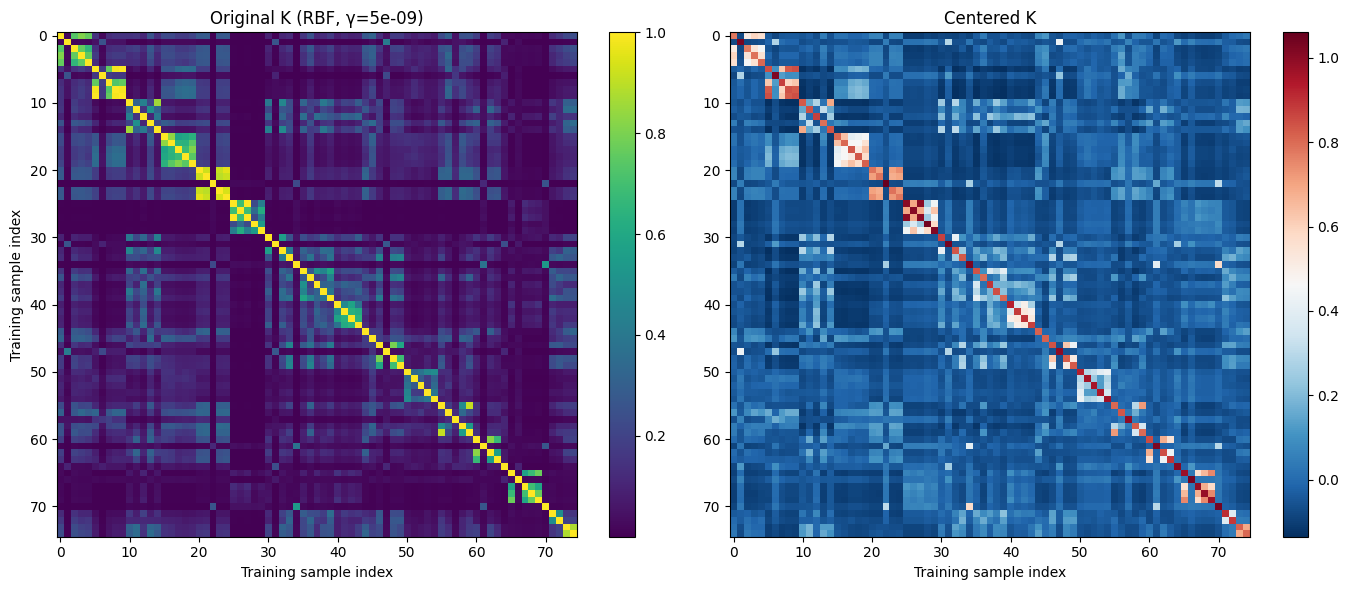

In [5]:
# K_c = K - 1_N K - K 1_N + 1_N K 1_N
N = K_train.shape[0]
one_N = np.ones((N, N)) / N

K_centered = K_train - one_N @ K_train - K_train @ one_N + one_N @ K_train @ one_N

print(f"Centered kernel matrix shape: {K_centered.shape}")
print(f"Row mean (should ≈ 0): {np.abs(K_centered.mean(axis=1)).max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(K_train, cmap='viridis', aspect='auto')
axes[0].set_title(f"Original K (RBF, γ={gamma})")
axes[0].set_xlabel("Training sample index")
axes[0].set_ylabel("Training sample index")
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(K_centered, cmap='RdBu_r', aspect='auto')
axes[1].set_title("Centered K")
axes[1].set_xlabel("Training sample index")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

### Eigendecomposition and Normalization

Number of positive eigenvalues: 72 / 75
Top 10 eigenvalues: [5.48093892 4.66508728 3.4058762  2.97278208 2.68648627 2.54838013
 2.46587718 2.32788058 2.22808848 2.00559738]
alphas shape: (75, 72)


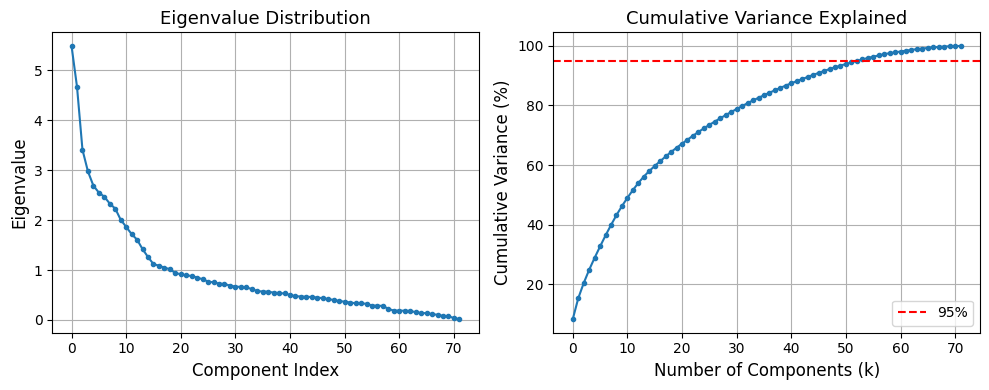


Components needed to reach 95% cumulative variance: 54


In [6]:
eigenvalues, eigenvectors = np.linalg.eigh(K_centered)

# Sort by descending eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Keep only positive eigenvalues (discard numerical noise)
pos_mask = eigenvalues > 1e-10
eigenvalues = eigenvalues[pos_mask]
eigenvectors = eigenvectors[:, pos_mask]

print(f"Number of positive eigenvalues: {len(eigenvalues)} / {K_centered.shape[0]}")
print(f"Top 10 eigenvalues: {eigenvalues[:10]}")

# Normalize: alpha^(m) = eigenvector^(m) / sqrt(lambda_m)
alphas = eigenvectors / np.sqrt(eigenvalues)

print(f"alphas shape: {alphas.shape}")

# ====================================================================
# Visualize Eigenvalue Distribution
# ====================================================================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(eigenvalues, marker='o', markersize=3)
plt.xlabel("Component Index", fontsize=12)
plt.ylabel("Eigenvalue", fontsize=12)
plt.title("Eigenvalue Distribution", fontsize=13)
plt.grid(True)

cumulative_ratio = np.cumsum(eigenvalues) / np.sum(eigenvalues) * 100
plt.subplot(1, 2, 2)
plt.plot(cumulative_ratio, marker='o', markersize=3)
plt.xlabel("Number of Components (k)", fontsize=12)
plt.ylabel("Cumulative Variance (%)", fontsize=12)
plt.title("Cumulative Variance Explained", fontsize=13)
plt.axhline(y=95, color='r', linestyle='--', label='95%')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

k_95 = np.argmax(cumulative_ratio >= 95) + 1
print(f"\nComponents needed to reach 95% cumulative variance: {k_95}")

### KPCA Projection Visualization


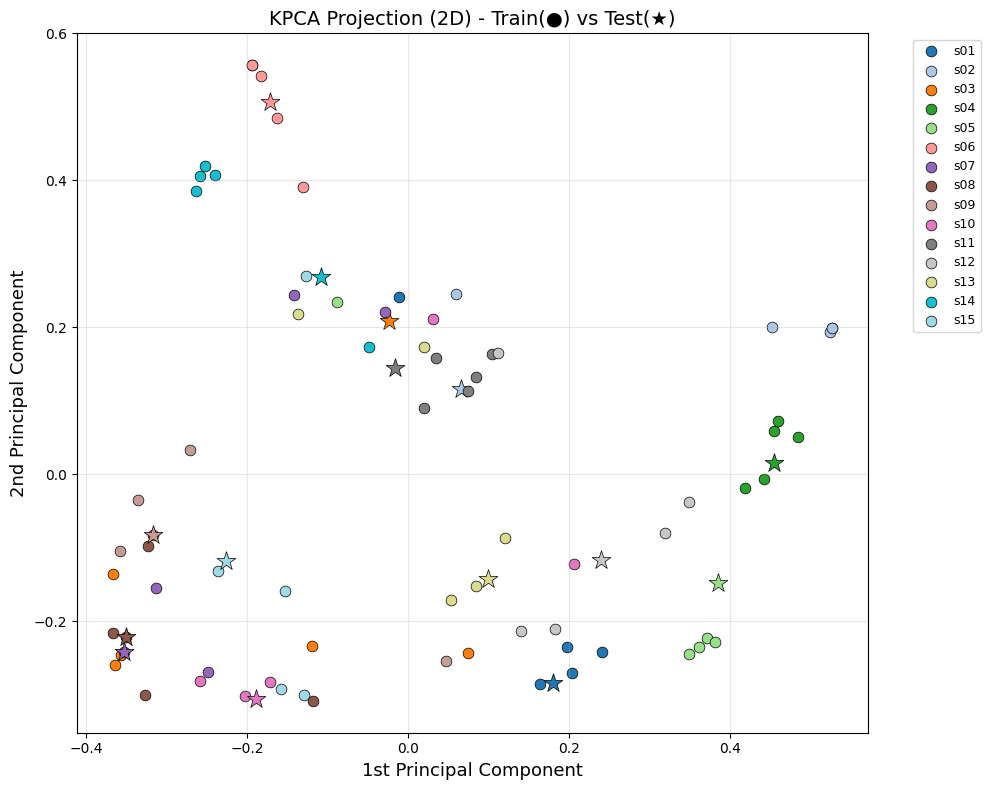

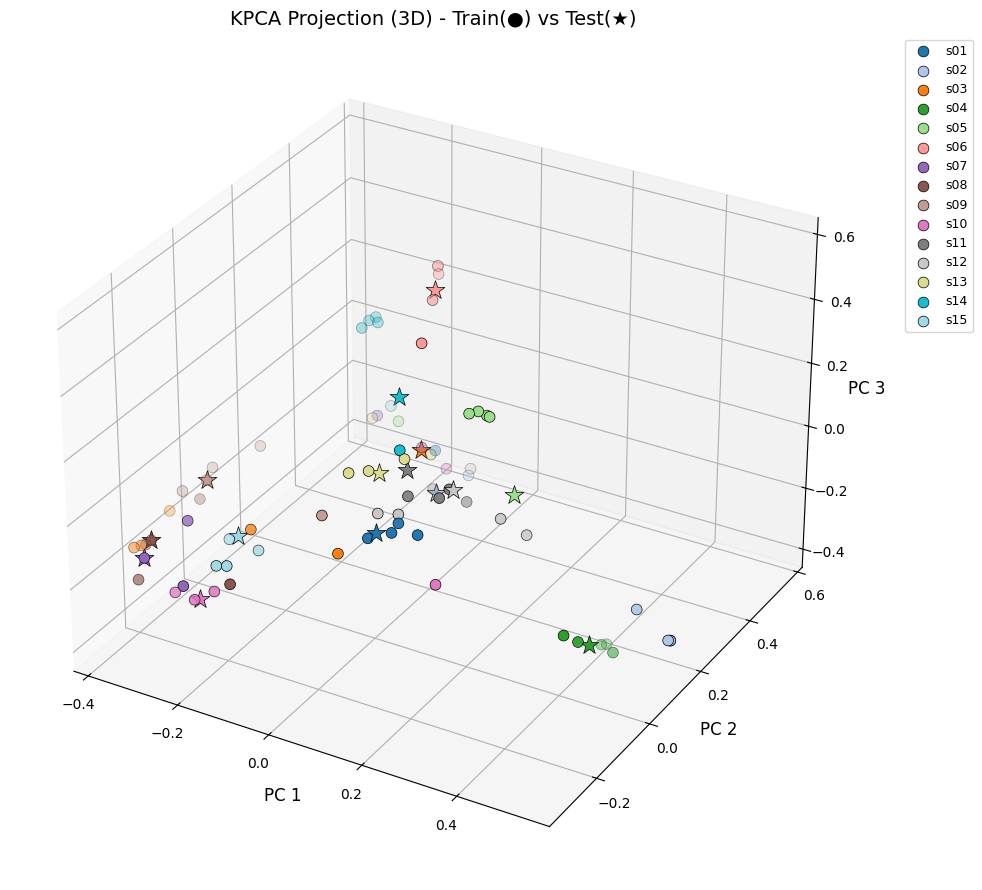

In [7]:
# Full projection onto all components
X_train_proj = K_centered @ alphas
K_test = rbf_kernel(X_test, X_train, gamma=gamma)
N_train = X_train.shape[0]
N_test = X_test.shape[0]
one_N_test = np.ones((N_test, N_train)) / N_train
K_test_centered = K_test - one_N_test @ K_train - K_test @ one_N + one_N_test @ K_train @ one_N
X_test_proj = K_test_centered @ alphas

# First 3 components for visualization only
X_train_3d = X_train_proj[:, :3]
X_test_3d = X_test_proj[:, :3]

# Assign a color to each person
unique_labels = sorted(set(y_train))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}


# 2D Scatter Plot
plt.figure(figsize=(10, 8))

for label in unique_labels:
    mask_tr = y_train == label
    plt.scatter(X_train_3d[mask_tr, 0], X_train_3d[mask_tr, 1],
                color=label_to_color[label], label=f"{label}",
                marker='o', s=60, edgecolors='black', linewidths=0.5)
    mask_te = y_test == label
    if np.any(mask_te):
        plt.scatter(X_test_3d[mask_te, 0], X_test_3d[mask_te, 1],
                    color=label_to_color[label],
                    marker='*', s=200, edgecolors='black', linewidths=0.5)

plt.xlabel("1st Principal Component", fontsize=13)
plt.ylabel("2nd Principal Component", fontsize=13)
plt.title("KPCA Projection (2D) - Train(●) vs Test(★)", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3D Scatter Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for label in unique_labels:
    mask_tr = y_train == label
    ax.scatter(X_train_3d[mask_tr, 0], X_train_3d[mask_tr, 1], X_train_3d[mask_tr, 2],
               color=label_to_color[label], label=f"{label}",
               marker='o', s=60, edgecolors='black', linewidths=0.5)
    mask_te = y_test == label
    if np.any(mask_te):
        ax.scatter(X_test_3d[mask_te, 0], X_test_3d[mask_te, 1], X_test_3d[mask_te, 2],
                   color=label_to_color[label],
                   marker='*', s=200, edgecolors='black', linewidths=0.5)

ax.set_xlabel("PC 1", fontsize=12)
ax.set_ylabel("PC 2", fontsize=12)
ax.set_zlabel("PC 3", fontsize=12)
ax.set_title("KPCA Projection (3D) - Train(●) vs Test(★)", fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

Using top 30 components
Accuracy: 93.33%  (14 / 15 correct)

Sample   True         Predicted    OK
----------------------------------------
0        s01          s01          ✓
1        s02          s02          ✓
2        s03          s07          ✗
3        s04          s04          ✓
4        s05          s05          ✓
5        s06          s06          ✓
6        s07          s07          ✓
7        s08          s08          ✓
8        s09          s09          ✓
9        s10          s10          ✓
10       s11          s11          ✓
11       s12          s12          ✓
12       s13          s13          ✓
13       s14          s14          ✓
14       s15          s15          ✓

Best k = 30, accuracy = 93.33%


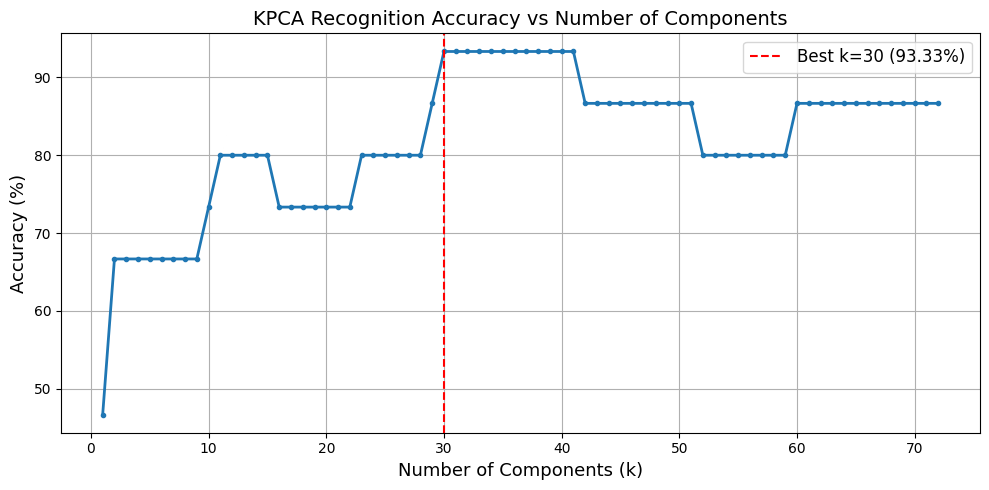

In [8]:
# ====================================================================
# 1-NN Classification with KPCA Projections
# ====================================================================

def nearest_neighbor_classify(X_train_proj, y_train, X_test_proj):
    """1-nearest-neighbour classifier using Euclidean distance (vectorized)."""
    # (n_test, n_train) distance matrix in one shot
    dists = np.linalg.norm(
        X_test_proj[:, np.newaxis, :] - X_train_proj[np.newaxis, :, :], axis=2
    )
    return y_train[np.argmin(dists, axis=1)]


# --- Single-k evaluation ---
k = 30
predictions = nearest_neighbor_classify(X_train_proj[:, :k], y_train, X_test_proj[:, :k])

accuracy = np.mean(predictions == y_test) * 100
print(f"Using top {k} components")
print(f"Accuracy: {accuracy:.2f}%  ({np.sum(predictions == y_test)} / {len(y_test)} correct)")

# --- Per-sample results ---
print(f"\n{'Sample':<8} {'True':<12} {'Predicted':<12} {'OK'}")
print("-" * 40)
for i in range(len(y_test)):
    mark = "✓" if predictions[i] == y_test[i] else "✗"
    print(f"{i:<8} {y_test[i]:<12} {predictions[i]:<12} {mark}")

# --- Sweep k: find the optimal number of components ---
max_k = X_train_proj.shape[1]

# Precompute per-component squared differences: (n_test, n_train, max_k)
# Cumulative sum means cum_dist_sq[:, :, k-1] = squared distance using first k components.
diff_sq = (X_test_proj[:, np.newaxis, :] - X_train_proj[np.newaxis, :, :]) ** 2
cum_dist_sq = np.cumsum(diff_sq, axis=2)

acc_list = [
    np.mean(y_train[np.argmin(cum_dist_sq[:, :, k - 1], axis=1)] == y_test) * 100
    for k in range(1, max_k + 1)
]

k_list = list(range(1, max_k + 1))
best_k = k_list[np.argmax(acc_list)]
best_acc = max(acc_list)
print(f"\nBest k = {best_k}, accuracy = {best_acc:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(k_list, acc_list, marker='o', markersize=3, linewidth=2)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k} ({best_acc:.2f}%)')
plt.xlabel("Number of Components (k)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("KPCA Recognition Accuracy vs Number of Components", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Improvement: KPCA + LDA
Apply LDA on top of KPCA features to maximize class separability in the kernel-induced feature space.

Best KPCA-only accuracy:  93.33% (gamma=5e-09, k=30)
Best KPCA+LDA accuracy:   100.00% (gamma=1e-11, KPCA_k=20)
Improvement over baseline KPCA: +13.33%

Sample   True         Predicted    OK
----------------------------------------
0        s01          s01          ✓
1        s02          s02          ✓
2        s03          s03          ✓
3        s04          s04          ✓
4        s05          s05          ✓
5        s06          s06          ✓
6        s07          s07          ✓
7        s08          s08          ✓
8        s09          s09          ✓
9        s10          s10          ✓
10       s11          s11          ✓
11       s12          s12          ✓
12       s13          s13          ✓
13       s14          s14          ✓
14       s15          s15          ✓


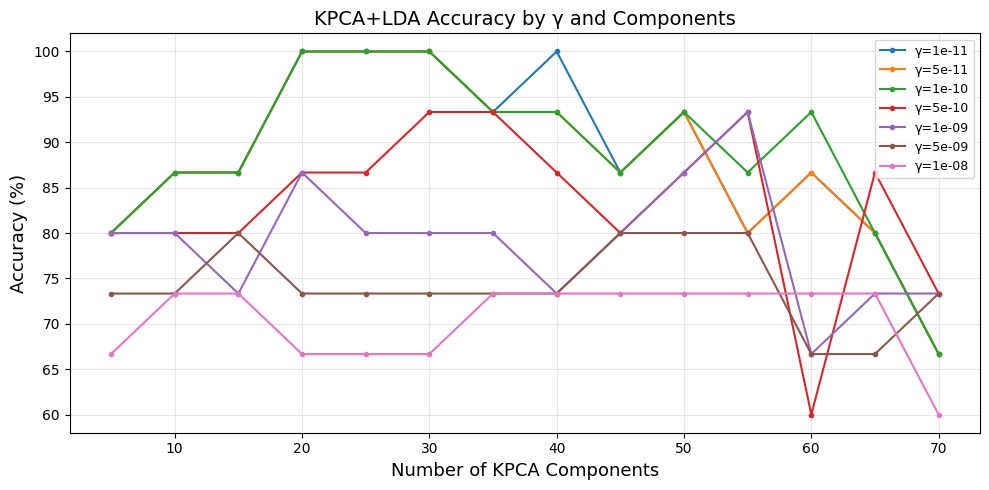

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ====================================================================
# KPCA + LDA: sweep gamma AND KPCA dimensions to find optimal config
# ====================================================================
gamma_candidates = [1e-11, 5e-11, 1e-10, 5e-10, 1e-9, 5e-9, 1e-8]
overall_best_acc = 0
overall_best_cfg = ""

results_for_plot = {}  # {gamma: {k: acc}}

for g in gamma_candidates:
    K_tr = rbf_kernel(X_train, X_train, g)
    N = K_tr.shape[0]
    one_N_mat = np.ones((N, N)) / N
    K_c_g = K_tr - one_N_mat @ K_tr - K_tr @ one_N_mat + one_N_mat @ K_tr @ one_N_mat

    ev_g, evec_g = np.linalg.eigh(K_c_g)
    idx_g = np.argsort(ev_g)[::-1]
    ev_g = ev_g[idx_g]; evec_g = evec_g[:, idx_g]
    pos_g = ev_g > 1e-10
    ev_g = ev_g[pos_g]; evec_g = evec_g[:, pos_g]
    al_g = evec_g / np.sqrt(ev_g)
    Xtr_p = K_c_g @ al_g

    K_te_g = rbf_kernel(X_test, X_train, g)
    N_te = X_test.shape[0]
    one_te_mat = np.ones((N_te, N)) / N
    K_te_c_g = K_te_g - one_te_mat @ K_tr - K_te_g @ one_N_mat + one_te_mat @ K_tr @ one_N_mat
    Xte_p = K_te_c_g @ al_g

    kpca_k_list_g = list(range(5, min(Xtr_p.shape[1], 70) + 1, 5))
    accs_g = []
    for kk in kpca_k_list_g:
        try:
            lda = LinearDiscriminantAnalysis()
            X_tr_lda = lda.fit_transform(Xtr_p[:, :kk], y_train)
            X_te_lda = lda.transform(Xte_p[:, :kk])
            dists_lda = np.linalg.norm(
                X_te_lda[:, np.newaxis, :] - X_tr_lda[np.newaxis, :, :], axis=2
            )
            preds_lda = y_train[np.argmin(dists_lda, axis=1)]
            acc = np.mean(preds_lda == y_test) * 100
            accs_g.append(acc)
            if acc > overall_best_acc:
                overall_best_acc = acc
                overall_best_cfg = f"gamma={g:.0e}, KPCA_k={kk}"
                best_g = g
                best_kk = kk
        except Exception:
            accs_g.append(float('nan'))
    results_for_plot[g] = (kpca_k_list_g, accs_g)

print(f"Best KPCA-only accuracy:  {best_gamma_acc * 100:.2f}% (gamma={best_gamma:.0e}, k={best_gamma_k})")
print(f"Best KPCA+LDA accuracy:   {overall_best_acc:.2f}% ({overall_best_cfg})")
print(f"Improvement over baseline KPCA: +{overall_best_acc - 86.67:.2f}%")

# Re-run with optimal config for per-sample results
K_tr_opt = rbf_kernel(X_train, X_train, best_g)
N_opt = K_tr_opt.shape[0]; one_N_opt = np.ones((N_opt, N_opt)) / N_opt
K_c_opt = K_tr_opt - one_N_opt @ K_tr_opt - K_tr_opt @ one_N_opt + one_N_opt @ K_tr_opt @ one_N_opt
ev_o, evec_o = np.linalg.eigh(K_c_opt)
idx_o = np.argsort(ev_o)[::-1]; ev_o = ev_o[idx_o]; evec_o = evec_o[:, idx_o]
pos_o = ev_o > 1e-10; ev_o = ev_o[pos_o]; evec_o = evec_o[:, pos_o]
al_o = evec_o / np.sqrt(ev_o)
Xtr_opt = K_c_opt @ al_o

K_te_opt = rbf_kernel(X_test, X_train, best_g)
one_te_o = np.ones((X_test.shape[0], N_opt)) / N_opt
K_te_c_opt = K_te_opt - one_te_o @ K_tr_opt - K_te_opt @ one_N_opt + one_te_o @ K_tr_opt @ one_N_opt
Xte_opt = K_te_c_opt @ al_o

lda_opt = LinearDiscriminantAnalysis()
X_tr_l_opt = lda_opt.fit_transform(Xtr_opt[:, :best_kk], y_train)
X_te_l_opt = lda_opt.transform(Xte_opt[:, :best_kk])
dists_opt = np.linalg.norm(X_te_l_opt[:, np.newaxis, :] - X_tr_l_opt[np.newaxis, :, :], axis=2)
preds_opt = y_train[np.argmin(dists_opt, axis=1)]

print(f"\n{'Sample':<8} {'True':<12} {'Predicted':<12} {'OK'}")
print("-" * 40)
for i in range(len(y_test)):
    mark = "\u2713" if preds_opt[i] == y_test[i] else "\u2717"
    print(f"{i:<8} {y_test[i]:<12} {preds_opt[i]:<12} {mark}")

# Plot
plt.figure(figsize=(10, 5))
for g, (ks, accs) in results_for_plot.items():
    plt.plot(ks, accs, marker='o', markersize=3, label=f'\u03b3={g:.0e}')
plt.xlabel("Number of KPCA Components", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("KPCA+LDA Accuracy by \u03b3 and Components", fontsize=14)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Effect of Training Size on KPCA Recognition Accuracy
Sweep n_train from 1 to 10, for each training size tune gamma and evaluate KPCA accuracy across different numbers of components k.

n_train =  2 | gamma = 1e-11 | max_k =  29 | best accuracy = 73.33% at k = 17


n_train =  3 | gamma = 1e-11 | max_k =  44 | best accuracy = 80.00% at k = 11


n_train =  4 | gamma = 1e-11 | max_k =  58 | best accuracy = 86.67% at k = 21


n_train =  5 | gamma = 5e-09 | max_k =  72 | best accuracy = 93.33% at k = 30


n_train =  6 | gamma = 1e-11 | max_k =  88 | best accuracy = 80.00% at k = 22


n_train =  7 | gamma = 5e-09 | max_k = 101 | best accuracy = 73.33% at k = 16


n_train =  8 | gamma = 1e-11 | max_k = 113 | best accuracy = 100.00% at k = 52


n_train =  9 | gamma = 1e-11 | max_k = 128 | best accuracy = 93.33% at k = 18


n_train = 10 | gamma = 1e-11 | max_k = 142 | best accuracy = 86.67% at k = 55


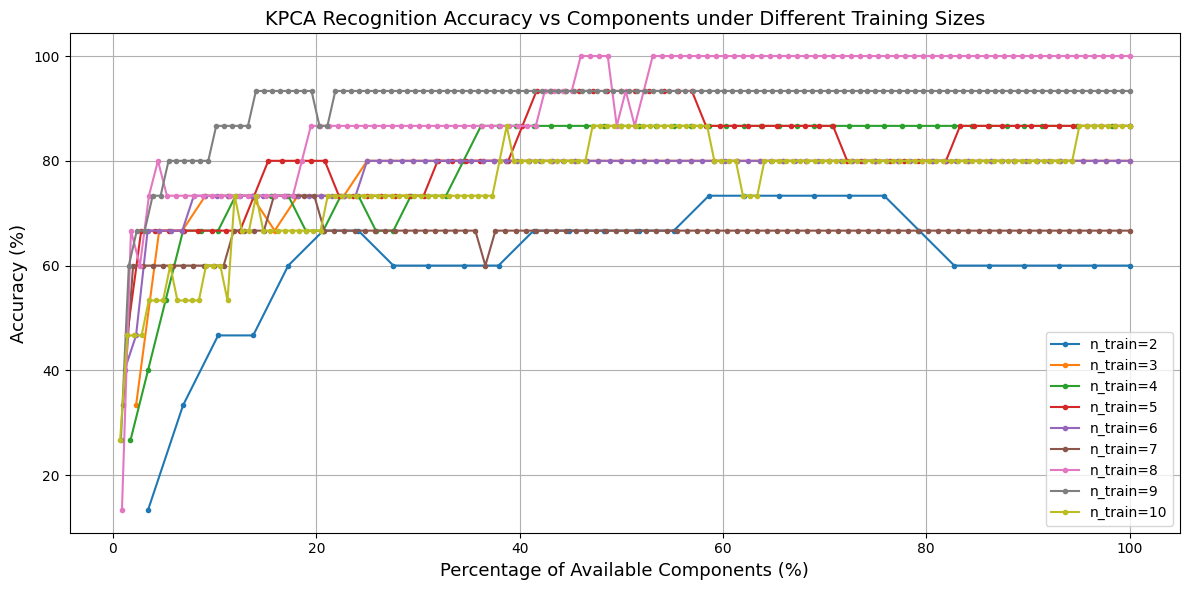

In [10]:
# ====================================================================
# KPCA Accuracy vs k under Different Training Sizes
# ====================================================================

n_train_list = list(range(2, 11))
gamma_candidates = [1e-11, 5e-11, 1e-10, 5e-10, 1e-9, 5e-9, 1e-8, 5e-8]
kpca_accuracy_data = {}

for n_tr in n_train_list:
    tr_imgs, tr_labels, te_imgs, te_labels = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])
    X_te = np.array([img.flatten() for img in te_imgs])
    y_tr = np.array(tr_labels)
    y_te = np.array(te_labels)

    N_tr = X_tr.shape[0]

    # --- Auto-tune gamma for this n_train ---
    best_g, best_g_acc = None, 0
    for g in gamma_candidates:
        K_tr = rbf_kernel(X_tr, X_tr, g)
        one_N_tr = np.ones((N_tr, N_tr)) / N_tr
        K_c = K_tr - one_N_tr @ K_tr - K_tr @ one_N_tr + one_N_tr @ K_tr @ one_N_tr

        ev, evec = np.linalg.eigh(K_c)
        idx = np.argsort(ev)[::-1]; ev = ev[idx]; evec = evec[:, idx]
        pos = ev > 1e-10; ev = ev[pos]; evec = evec[:, pos]
        al = evec / np.sqrt(ev)
        Xtr_p = K_c @ al

        K_te = rbf_kernel(X_te, X_tr, g)
        N_te = X_te.shape[0]
        one_te = np.ones((N_te, N_tr)) / N_tr
        K_te_c = K_te - one_te @ K_tr - K_te @ one_N_tr + one_te @ K_tr @ one_N_tr
        Xte_p = K_te_c @ al

        max_k = Xtr_p.shape[1]
        for k in range(1, max_k + 1):
            dists = np.linalg.norm(Xte_p[:, np.newaxis, :k] - Xtr_p[np.newaxis, :, :k], axis=2)
            preds = y_tr[np.argmin(dists, axis=1)]
            acc = np.mean(preds == y_te)
            if acc > best_g_acc:
                best_g_acc = acc
                best_g = g

    # --- Compute full accuracy curve with best gamma ---
    K_tr = rbf_kernel(X_tr, X_tr, best_g)
    one_N_tr = np.ones((N_tr, N_tr)) / N_tr
    K_c = K_tr - one_N_tr @ K_tr - K_tr @ one_N_tr + one_N_tr @ K_tr @ one_N_tr

    ev, evec = np.linalg.eigh(K_c)
    idx = np.argsort(ev)[::-1]; ev = ev[idx]; evec = evec[:, idx]
    pos = ev > 1e-10; ev = ev[pos]; evec = evec[:, pos]
    al = evec / np.sqrt(ev)
    Xtr_p = K_c @ al

    K_te = rbf_kernel(X_te, X_tr, best_g)
    N_te = X_te.shape[0]
    one_te = np.ones((N_te, N_tr)) / N_tr
    K_te_c = K_te - one_te @ K_tr - K_te @ one_N_tr + one_te @ K_tr @ one_N_tr
    Xte_p = K_te_c @ al

    max_k = Xtr_p.shape[1]
    k_list = list(range(1, max_k + 1))
    accs = []
    for k in k_list:
        dists = np.linalg.norm(Xte_p[:, np.newaxis, :k] - Xtr_p[np.newaxis, :, :k], axis=2)
        preds = y_tr[np.argmin(dists, axis=1)]
        accs.append(np.mean(preds == y_te) * 100)

    kpca_accuracy_data[n_tr] = {
        'k_list': k_list,
        'accuracy': accs,
        'best_gamma': best_g,
        'max_k': max_k
    }
    print(f"n_train = {n_tr:>2d} | gamma = {best_g:.0e} | max_k = {max_k:>3d} "
          f"| best accuracy = {max(accs):.2f}% at k = {k_list[np.argmax(accs)]}")

# --- Plot: Accuracy vs k (percentage of available components) ---
plt.figure(figsize=(12, 6))
for n_tr in n_train_list:
    data = kpca_accuracy_data[n_tr]
    k_pct = [k / data['max_k'] * 100 for k in data['k_list']]
    plt.plot(k_pct, data['accuracy'],
             label=f"n_train={n_tr}", marker='o', markersize=3)
plt.xlabel("Percentage of Available Components (%)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("KPCA Recognition Accuracy vs Components under Different Training Sizes", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

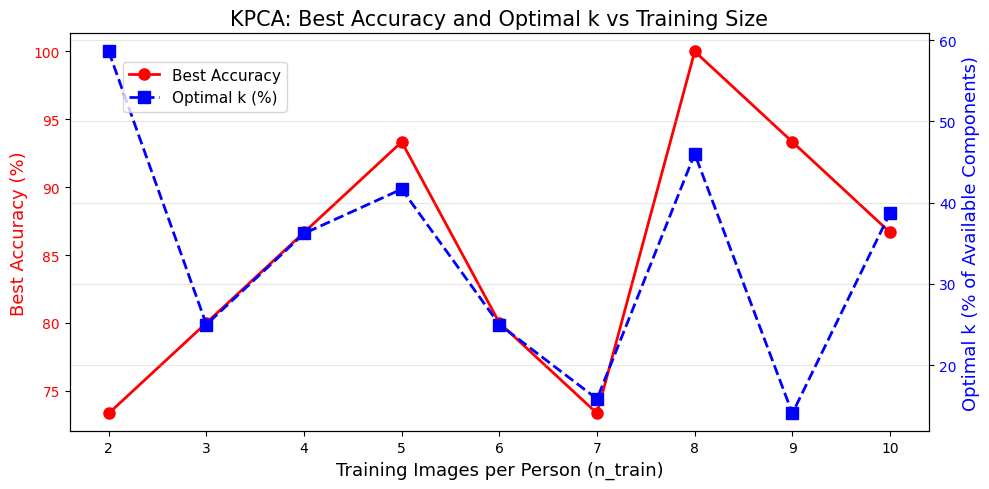

 n_train      gamma  max_k  best_k     k%   Accuracy
----------------------------------------------------
       2      1e-11     29      17  58.6%     73.33%
       3      1e-11     44      11  25.0%     80.00%
       4      1e-11     58      21  36.2%     86.67%
       5      5e-09     72      30  41.7%     93.33%
       6      1e-11     88      22  25.0%     80.00%
       7      5e-09    101      16  15.8%     73.33%
       8      1e-11    113      52  46.0%    100.00%
       9      1e-11    128      18  14.1%     93.33%
      10      1e-11    142      55  38.7%     86.67%


In [11]:
# ====================================================================
# Best Accuracy and Optimal k vs Training Size
# ====================================================================

n_trains = []
best_accs = []
best_ks = []
best_k_pcts = []
best_gammas = []

for n_tr in n_train_list:
    data = kpca_accuracy_data[n_tr]
    accs = data['accuracy']
    k_list = data['k_list']
    best_idx = np.argmax(accs)
    n_trains.append(n_tr)
    best_accs.append(accs[best_idx])
    best_ks.append(k_list[best_idx])
    best_k_pcts.append(k_list[best_idx] / data['max_k'] * 100)
    best_gammas.append(data['best_gamma'])

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(n_trains, best_accs, 'ro-', linewidth=2, markersize=8, label='Best Accuracy')
ax1.set_xlabel("Training Images per Person (n_train)", fontsize=13)
ax1.set_ylabel("Best Accuracy (%)", fontsize=13, color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xticks(n_trains)

ax2 = ax1.twinx()
ax2.plot(n_trains, best_k_pcts, 'bs--', linewidth=2, markersize=8, label='Optimal k (%)')
ax2.set_ylabel("Optimal k (% of Available Components)", fontsize=13, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88), fontsize=11)
plt.title("KPCA: Best Accuracy and Optimal k vs Training Size", fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table
print(f"{'n_train':>8} {'gamma':>10} {'max_k':>6} {'best_k':>7} {'k%':>6} {'Accuracy':>10}")
print("-" * 52)
for i, n_tr in enumerate(n_trains):
    print(f"{n_tr:>8d} {best_gammas[i]:>10.0e} {kpca_accuracy_data[n_tr]['max_k']:>6d} "
          f"{best_ks[i]:>7d} {best_k_pcts[i]:>5.1f}% {best_accs[i]:>9.2f}%")

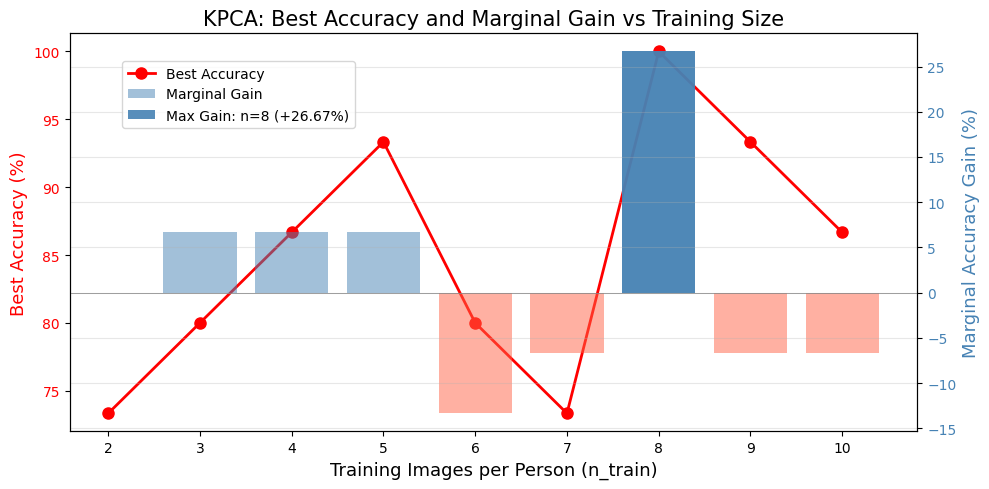

 n_train   Accuracy   Marginal Gain
-----------------------------------
       2     73.33%               -
       3     80.00%          +6.67%
       4     86.67%          +6.67%
       5     93.33%          +6.67%
       6     80.00%         -13.33%
       7     73.33%          -6.67%
       8    100.00%         +26.67%
       9     93.33%          -6.67%
      10     86.67%          -6.67%


In [12]:
# ====================================================================
# Marginal Accuracy Gain vs Training Size
# ====================================================================

marginal_gain = [best_accs[i] - best_accs[i-1] for i in range(1, len(best_accs))]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(n_trains, best_accs, 'ro-', linewidth=2, markersize=8, label='Best Accuracy')
ax1.set_xlabel("Training Images per Person (n_train)", fontsize=13)
ax1.set_ylabel("Best Accuracy (%)", fontsize=13, color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xticks(n_trains)

ax2 = ax1.twinx()
bar_x = n_trains[1:]
bar_colors = ['tomato' if g < 0 else 'steelblue' for g in marginal_gain]
ax2.bar(bar_x, marginal_gain, color=bar_colors, alpha=0.5, label='Marginal Gain')
# Highlight max positive gain
pos_gains = [g for g in marginal_gain if g > 0]
if pos_gains:
    max_gain_idx = np.argmax(marginal_gain)
    ax2.bar(bar_x[max_gain_idx], marginal_gain[max_gain_idx], color='steelblue', alpha=0.9,
            label=f'Max Gain: n={bar_x[max_gain_idx]} (+{marginal_gain[max_gain_idx]:.2f}%)')
ax2.set_ylabel("Marginal Accuracy Gain (%)", fontsize=13, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.axhline(y=0, color='gray', linewidth=0.5)

fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88), fontsize=10)
plt.title("KPCA: Best Accuracy and Marginal Gain vs Training Size", fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print table
print(f"{'n_train':>8} {'Accuracy':>10} {'Marginal Gain':>15}")
print("-" * 35)
for i, n_tr in enumerate(n_trains):
    gain = f"{marginal_gain[i-1]:+.2f}%" if i > 0 else "    -"
    print(f"{n_tr:>8d} {best_accs[i]:>9.2f}% {gain:>15}")